## Predicting Inventory Needs

- **The Business Problem:**

A global e-commerce platform needs to predict how many units of a product will sell over the next 30 days based on historical sales, seasonal trends, and promotional events.

- **Solution:** LSTM (Long Short-Term Memory)

Standard ANNs treat every data point as independent. However, sales on Monday are often related to sales on Sunday. We use an LSTM (a sophisticated type of RNN) because it can remember long-term patterns (like a yearly holiday spike) and short-term patterns (like a weekend surge).

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# Load a clean time-series dataset (Demand over time)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, usecols=[1])
data = df.values.astype('float32')

# Normalize the data (Crucial for LSTMs)
scaler = MinMaxScaler(feature_range=(-1, 1))
train_data_normalized = scaler.fit_transform(data)

In [11]:
# Prepare the "Windowed" Sequences
# LSTMs need to look at a sequence of past days to predict the next one.
def create_inout_sequences(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(L-tw):
        train_seq = input_data[i:i+tw]
        train_label = input_data[i+tw:i+tw+1]
        inout_seq.append((train_seq ,train_label))
    return inout_seq

train_window = 12 # Looking at 12 months to predict the 13th
train_inout_seq = create_inout_sequences(torch.FloatTensor(train_data_normalized), train_window)

In [12]:
# LSTM Model Using pytorch
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=100, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size)
        self.linear = nn.Linear(hidden_layer_size, output_size)
        self.hidden_cell = (torch.zeros(1,1,self.hidden_layer_size),
                            torch.zeros(1,1,self.hidden_layer_size))

    def forward(self, input_seq):
        lstm_out, self.hidden_cell = self.lstm(input_seq.view(len(input_seq) ,1, -1), self.hidden_cell)
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions[-1]

In [13]:
# Training
model = LSTMModel()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
for i in range(epochs):
    for seq, labels in train_inout_seq:
        optimizer.zero_grad()
        model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size),
                        torch.zeros(1, 1, model.hidden_layer_size))
        y_pred = model(seq)
        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()

    if i%25 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch:   1 loss: 0.00894228
epoch:  26 loss: 0.00055766


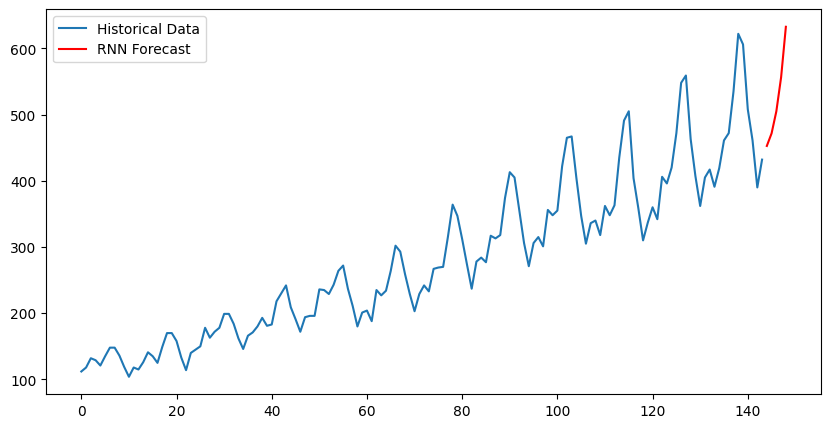

In [17]:
future_forecast = 5
test_inputs = train_data_normalized[-train_window:].tolist()

model.eval()

for i in range(future_forecast):
    seq = torch.FloatTensor(test_inputs[-train_window:])
    with torch.no_grad():
        model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size),
                             torch.zeros(1, 1, model.hidden_layer_size))
        # Append the new prediction to the input sequence
        test_inputs.append([model(seq).item()])

# Transform back to original scale
actual_predictions = scaler.inverse_transform(np.array(test_inputs[train_window:]).reshape(-1, 1))

# Plotting the forecast
plt.figure(figsize=(10,5))
plt.plot(df.values, label='Historical Data')
plt.plot(np.arange(len(df), len(df) + future_forecast), actual_predictions, label='RNN Forecast', color='red')
plt.legend()
plt.show()

This trained model forecast works like a digital brain that recognizes patterns over time. By looking at the blue line, the model learned that your business has a steady upward growth and a predictable seasonal cycle (the repeating waves). The red line shows the model's "future guess," where it successfully mimics those same peaks and drops to tell you exactly when to expect the next surge in demand. This allows you to plan ahead—stocking up before the red peak hits and slowing down once it starts to drop—so you don't waste money or run out of products.